In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)

In [3]:
print("Shape:")
print(df.shape)

print("\nInfo:")
df.info()

print("\nDescribe:")
print(df.describe())

Shape:
(891, 15)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Describe:
         survived      pclass         age   

In [4]:
missing_percentage = (df.isna().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]
print(missing_percentage)

age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


In [11]:
df["age"] = df["age"].fillna(df["age"].median())
df.dropna(subset=["embarked", "embark_town"],inplace=True)
df.drop(columns=["deck"], inplace=True)
df.isna().sum().sum()

np.int64(0)

In [12]:
print(df.isna().sum())
print(df.shape)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64
(889, 14)


### Missing Value Handling

The missing percentage I got is:

- age = 19.87%
- embarked = 0.22%
- deck = 77.22%
- embark_town = 0.22%

For age the missing percentage is between 5% and 30%, so I used median
imputation.

For embarked and embark_town the missing percentage is less than 5%,
so I dropped those rows.

Deck has around 77% missing values. Since most of the values are missing,
I dropped this column because imputing this much missing data may not be
reliable.

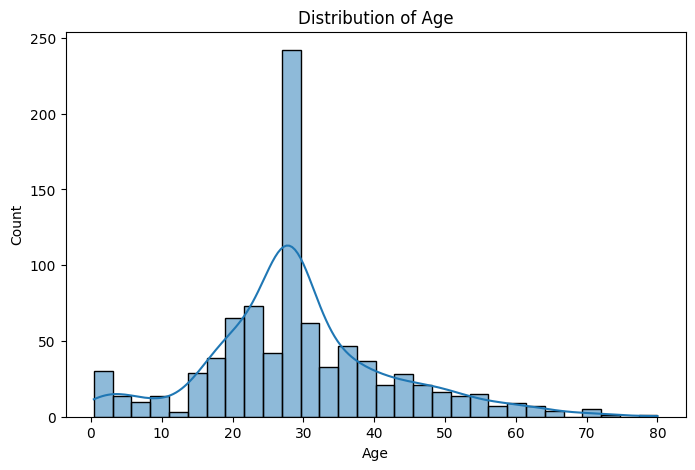

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df, x="age", kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

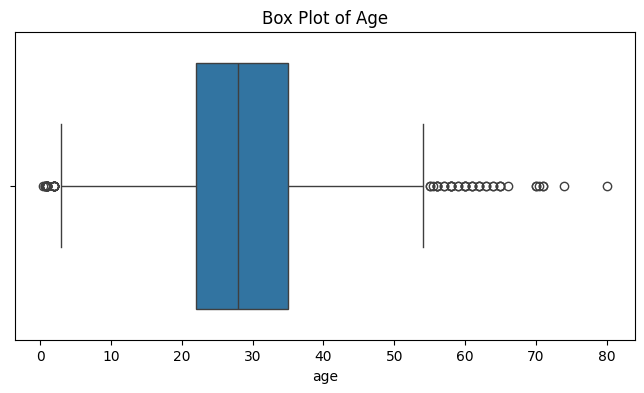

In [15]:
plt.figure(figsize=(8, 4))

sns.boxplot(df, x="age")

plt.title("Box Plot of Age")

plt.show()

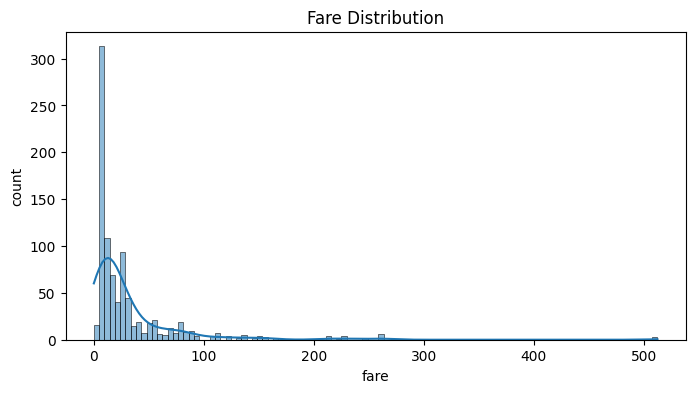

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(df,x="fare",kde=True)
plt.title("Fare Distribution")
plt.xlabel("fare")
plt.ylabel("count")
plt.show()

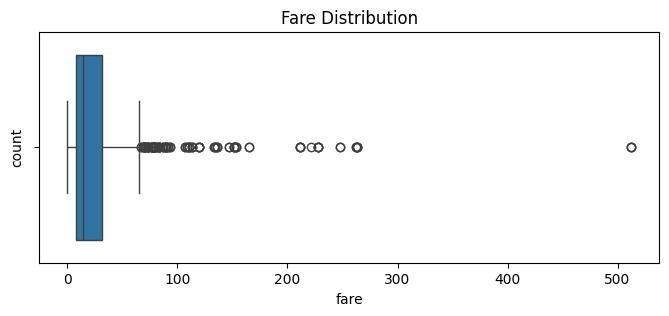

In [20]:
plt.figure(figsize=(8,3))
sns.boxplot(df,x="fare")
plt.title("Fare Distribution")
plt.xlabel("fare")
plt.ylabel("count")
plt.show()

In [22]:
for value in ["age", "fare"]:
  q1 = df[value].quantile(0.25)
  q3 = df[value].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  outliers = df[(df[value] < lower_bound) | (df[value] > upper_bound)]
  print(f"{value} lower limit:", lower_bound)
  print(f"{value} upper limit:", upper_bound)
  print(f"Number of {value} outliers:", len(outliers))

age lower limit: 2.5
age upper limit: 54.5
Number of age outliers: 65
fare lower limit: -26.7605
fare upper limit: 65.6563
Number of fare outliers: 114


In [23]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


### Univariate Analysis

Using the IQR method, I found 65 outliers in `age` and 114 outliers
in `fare`.

For fare:

- Mean = 32.09668087739032
- Median = 14.4542
- Mode = 8.05

The mean is greater than the median and mode. From this and the histogram,
I can see that the fare distribution is right-skewed. Higher fare values
are pulling the mean towards the right.

Right Skew: Mean > Median > Mode

In [25]:
for sex in ["male", "female"]:
  total = df[df["sex"] == sex]
  survived = df[(df["sex"] == sex) &(df["survived"] == 1)]
  survival_rate = len(survived) / len(total) * 100
  print(sex, "survival rate:", round(survival_rate, 2), "%")

male survival rate: 18.89 %
female survival rate: 74.04 %


In [27]:
for pclass in [1, 2, 3]:
  total = df[df["pclass"] == pclass]
  survived = df[(df["pclass"] == pclass) & (df["survived"] == 1)]
  survival_rate = len(survived) / len(total) *100
  print("Class", pclass,"survival rate:",round(survival_rate , 2), "%")

Class 1 survival rate: 62.62 %
Class 2 survival rate: 47.28 %
Class 3 survival rate: 24.24 %


In [28]:
for sex in ["male", "female"]:
  for pclass in [1, 2, 3]:
      total = df[(df["sex"] == sex) & (df["pclass"] == pclass)]
      survived = df[(df["sex"] == sex) &(df["pclass"] == pclass) & (df["survived"] == 1)]
      survival_rate = len(survived) / len(total) *100
      print(sex,"Class", pclass,"survival rate:",round(survival_rate, 2), "%")

male Class 1 survival rate: 36.89 %
male Class 2 survival rate: 15.74 %
male Class 3 survival rate: 13.54 %
female Class 1 survival rate: 96.74 %
female Class 2 survival rate: 92.11 %
female Class 3 survival rate: 50.0 %


In [29]:
correlation_columns = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df[correlation_columns].corr()
corr

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


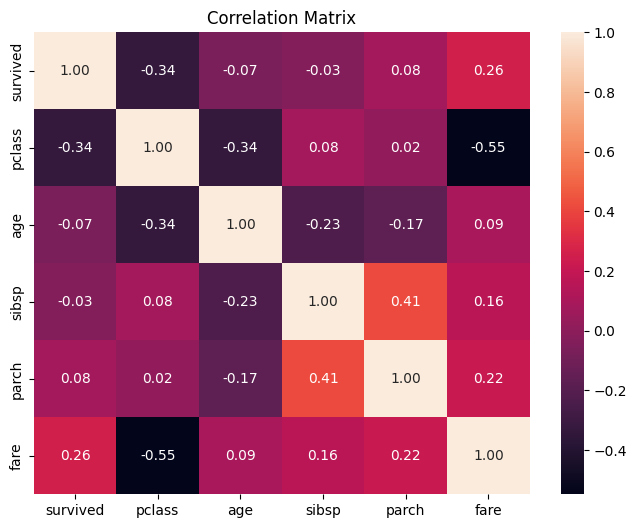

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [36]:
corr.iloc[1,0]

np.float64(-0.33554885935682505)

In [38]:
pairs = []
for i in range(len(correlation_columns)):
    for j in range(i+1, len(correlation_columns)):
        pairs.append((correlation_columns[i], correlation_columns[j], corr.loc[correlation_columns[i], correlation_columns[j]]))
sorted_pairs= sorted(pairs, key=lambda x: abs(x[2]), reverse = True)
print("Two strongest correlations:", sorted_pairs[:2])

Two strongest correlations: [('pclass', 'fare', np.float64(-0.5481932852366449)), ('sibsp', 'parch', np.float64(0.4145416380997264))]


### Correlation Analysis

The strongest correlation is between `pclass` and `fare` which is -0.55. It shows a moderate negative correlation. As the passenger class number increases, the fare generally decreases.

The second strongest correlation is between `sibsp` and `parch` which is 0.41. It shows a moderate positive correlation. Passengers travelling with siblings or spouse also tend to travel with parents or children.

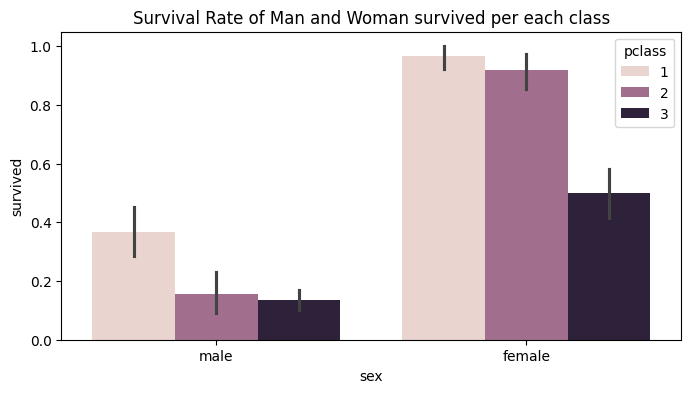

In [56]:
plt.figure(figsize=(8,4))
sns.barplot(df, x="sex", y="survived", hue="pclass")
plt.title("Survival Rate of Man and Woman survived per each class")
plt.xlabel("sex")
plt.ylabel("survived")
plt.show()

Females had a much higher survival rate than males in every passenger class.

First class passengers also had better survival compared to second and third class.

This shows that both sex and passenger class were strongly related to survival.

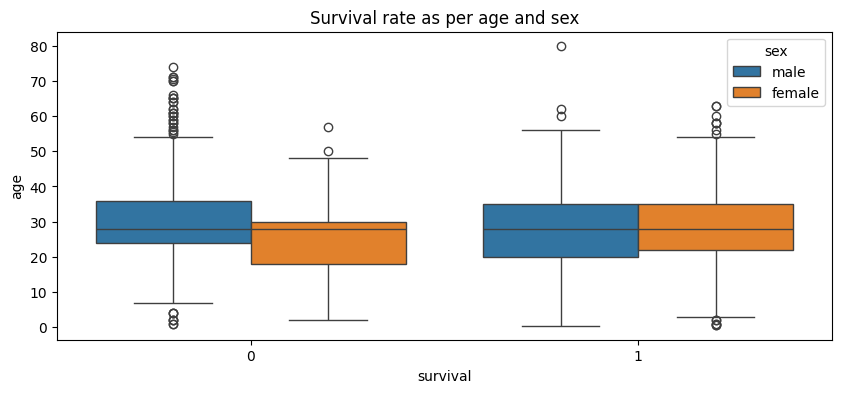

In [49]:
plt.figure(figsize=(10,4))
sns.boxplot(df,x="survived",y="age",hue="sex")
plt.title("Age Distribution for survival and sex")
plt.xlabel("survival")
plt.ylabel("age")
plt.show()

The median of both male and female of people who are survived is almost same.

Most of middle 50% of survived male and female passengers are roughly between 20 and 35 years old.

There are male infants who are died.

There are many old age male people who are died

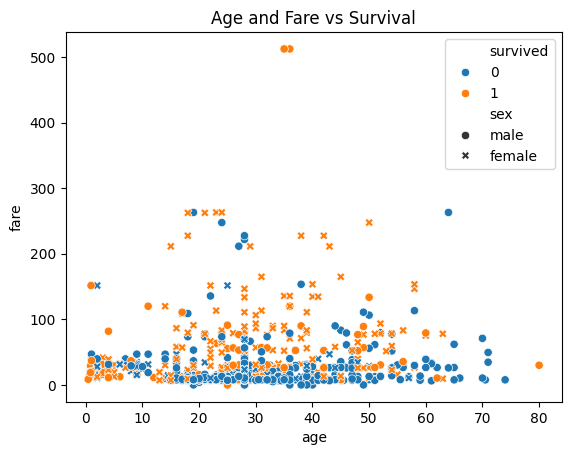

In [57]:
sns.scatterplot(df,x="age",y="fare",hue="survived",style="sex")
plt.title("Age and Fare vs Survival")
plt.xlabel("age")
plt.ylabel("fare")
plt.show()

Higher fares contain many survivors.

A large number of non-survivors paid lower fares.

Age does not clearly separate survival.

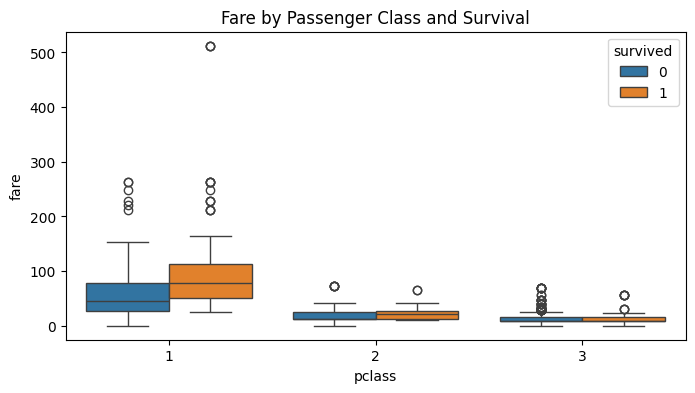

In [52]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="pclass", y="fare", hue="survived")
plt.title("Fare by Passenger Class and Survival")
plt.show()

In third class, the fare distributions of survived and not survived passengers are very close, so fare does not show much separation between the two groups in this class.

There is one extreme fare person who survived.

In first class, the median fare of survivors (1) is clearly higher than the median fare of non-survivors

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[["age_scaled","fare_scaled"]] = scaler.fit_transform(df[["age","fare"]])

In [55]:
print("Before scaling")
print(df[["age","fare"]].agg(["mean","std"]))
print("\nAfter scaling")
print(df[["age_scaled","fare_scaled"]].agg(["mean","std"]))

Before scaling
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After scaling
        age_scaled   fare_scaled
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


After standardizing age and fare, their mean became approximately 0 and standard deviation became approximately 1.

This shows that the standardization worked correctly.

This scaling is only for the EDA check. For modeling I will do the scaling separately inside the preprocessing pipeline. Because I know data leakage going to happen if we do fit_transform on whole dataset